# Exercício:

## 01 – Do exercício 2 da aula 15, exporte o objeto DataFrame contendo as frequências absolutas de cada aminoácido em cada proteína para .csv, instancie um objeto da classe DataFrame. Defina uma função que receba qualquer objeto composto unidimensional e que retorne as medidas de tendência central. Qual o valor de média, mediana e moda da Serina nos genes analisados? E do terceiro gene?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_amino = pd.read_csv("df_amino.csv", index_col=0, header=0)
df_amino

,M,K,Y,T,S,I,L,A,F,Q,...,G,D,P,E,N,H,W,R,gene,media_gene
0,5,21,7,6,13,9,14,9,11,10,...,7,10,2,9,10,2,1.0,8,interferon_gama,8.30
1,11,13,5,15,19,10,33,15,9,8,...,2,11,10,14,11,5,0.0,10,interleucina_12,10.95
2,6,14,3,13,19,9,28,18,11,14,...,7,8,11,16,11,2,1.0,9,interleucina_6,10.60
3,7,18,16,17,31,14,52,24,10,14,...,20,14,30,26,15,10,7.0,30,TGF-beta,19.50
4,2,8,7,10,20,12,30,19,10,13,...,17,7,15,16,7,4,2.0,14,TNF-alpha,11.65


In [4]:
def tendencia_central(dados):
    serie = pd.Series(dados)
    media = serie.mean()
    mediana = serie.median()
    moda = serie.mode()
    return media, mediana, moda

In [6]:
media, mediana, moda = tendencia_central(df_amino["S"])

print("Média:", media)
print("Mediana:", mediana)
print("Moda", moda.values)

Média: 20.4
Mediana: 19.0
Moda [19]


In [16]:
terceiro_gene = df_amino.iloc[2].drop(["gene", "media_gene"])
media, mediana, moda = tendencia_central(terceiro_gene)

print("Média:", media)
print("Mediana:", mediana)
print("Moda", moda.values)

Média: 10.6
Mediana: 10.0
Moda [np.int64(11)]


## 02 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne a amplitude. Qual o valor de amplitude da Isoleucina? E do último gene?

In [17]:
def amplitude(dados):
    s = pd.Series(dados)
    return s.max() - s.min()

In [21]:
amp_i = amplitude(df_amino["I"])
print(amp_i)

5


In [22]:
amp_u = amplitude(df_amino.iloc[-1].drop(["gene", "media_gene"]))
print(amp_u)

28


## 03 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne os quartis. Qual o valor do Q1, Q2 e Q3 da Metionina? E do primeiro gene?

In [23]:
def quartis(dados):
    s = pd.Series(dados)
    return {
        "Q1": s.quantile(0.25),
        "Q2": s.quantile(0.50),
        "Q3": s.quantile(0.75)
    }

In [24]:
q_m = quartis(df_amino["M"])
print(q_m)

{'Q1': np.float64(5.0), 'Q2': np.float64(6.0), 'Q3': np.float64(7.0)}


In [25]:
q_um = quartis(df_amino.iloc[0].drop(["gene", "media_gene"]))
print (q_um)

{'Q1': np.float64(5.75), 'Q2': np.float64(9.0), 'Q3': np.float64(10.0)}


## 04 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne o intervalo interquartil. Qual o valor do o intervalo interquartil da Ácido Glutâmico? E do penúltimo gene? Obtenha o box plot com as medidas de tendência central para a frequência de aa nesse gene.

In [26]:
def iqr(dados):
    s = pd.Series(dados)
    return s.quantile(0.75) - s.quantile(0.25)

In [27]:
iqr_e = iqr(df_amino["E"])
print(iqr_e)

2.0


In [28]:
iqr_p = iqr(df_amino.iloc[-2].drop(["gene", "media_gene"]))
print(iqr_p)

11.0


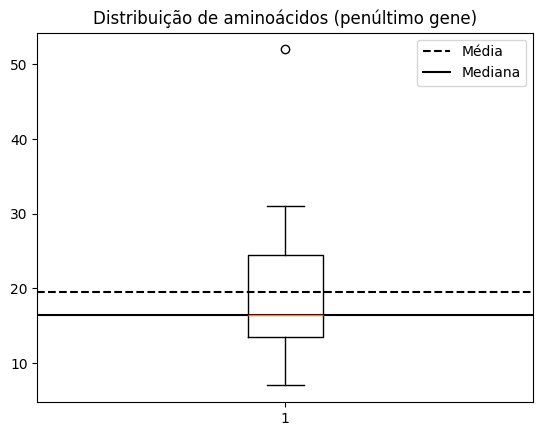

In [29]:
dados = df_amino.iloc[-2].drop(["gene", "media_gene"])
media_p = dados.mean()
mediana_p = dados.median()
plt.boxplot(dados)
plt.axhline(media_p, linestyle="--", label="Média", color="black")
plt.axhline(mediana_p, linestyle="-", label="Mediana", color="black")
plt.legend(loc="upper right")
plt.title("Distribuição de aminoácidos (penúltimo gene)")
plt.show()

## 05 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne a variância amostral não viciada. Qual o valor da variância da Prolina? E do terceiro gene?

In [30]:
def variancia(dados):
    s = pd.Series(dados)
    return s.var(ddof=1)

In [31]:
var_p = variancia(df_amino["P"])
print(var_p)

106.3


In [32]:
var_t = variancia(df_amino.iloc[2].drop(["gene", "media_gene"]))
print(var_t)

42.46315789473683


## 06 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne o desvio padrão. Qual o valor d o desvio padrão do Triptofano? E do gene de index -1?

In [33]:
def desvio(dados):
    s = pd.Series(dados)
    return s.std(ddof=1)

In [34]:
dp_w = desvio(df_amino["W"])
print(dp_w)

2.7748873851023217


In [35]:
dp_p = desvio(df_amino.iloc[-1].drop(["gene", "media_gene"]))
print(dp_p)

7.005824644349045


## 07 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne o coeficiente de variação. Qual o valor do coeficiente de variação da Leucina? E do gene de index 1?

In [36]:
def coef_variacao(dados):
    s = pd.Series(dados)
    return s.std(ddof=1) / s.mean()

In [37]:
cv_l = coef_variacao(df_amino["L"])
print(cv_l)

0.4341034193984392


In [38]:
cv_1 = coef_variacao(df_amino.iloc[1].drop(["gene", "media_gene"]))
print(cv_1)

0.626069650236897


## 08 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne as medidas resumo.
Obs.: Use um dicionário onde os index são os nomes e os valores as medidas.

In [39]:
def medidas_resumo(dados):
    s = pd.Series(dados)
    return {
        "media": s.mean(),
        "mediana": s.median(),
        "moda": s.mode().tolist(),
        "min": s.min(),
        "max": s.max(),
        "amplitude": s.max() - s.min(),
        "Q1": s.quantile(0.25),
        "Q2": s.quantile(0.5),
        "Q3": s.quantile(0.75),
        "IQR": s.quantile(0.75) - s.quantile(0.25),
        "variancia": s.var(ddof=1),
        "desvio padrao": s.std(ddof=1),
        "CV": s.std(ddof=1) / s.mean()
    }

In [41]:
exemplo = medidas_resumo(df_amino["S"])
pd.Series(exemplo)

media                20.4
mediana              19.0
moda                 [19]
min                    13
max                    31
amplitude              18
Q1                   19.0
Q2                   19.0
Q3                   20.0
IQR                   1.0
variancia            42.8
desvio padrao    6.542171
CV               0.320695
dtype: object

## 09 – Defina uma função que retorne qual o gene com o maior CV de frequência de aminoácidos. Obtenha os boxplot dos genes. Os dados concordam? Porque?

In [43]:
def maior_cv(df):
    cvs = {}
    for i in range(len(df)):
        linha = df.iloc[i].drop(["gene", "media_gene"])
        cv = linha.std(ddof=1) / linha.mean()
        cvs[df.iloc[i]["gene"]] = cv
    return max(cvs, key=cvs.get), cvs   

In [44]:
gene, valores = maior_cv(df_amino)

print(gene)
print(valores)

interleucina_12
{'interferon_gama': np.float64(0.5625357845748796), 'interleucina_12': np.float64(0.626069650236897), 'interleucina_6': np.float64(0.6147524652905293), 'TGF-beta': np.float64(0.5474160650248988), 'TNF-alpha': np.float64(0.6013583385707334)}


C:\Users\Livia\AppData\Local\Temp\ipykernel_7936\3303447612.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(dados.T, labels=df_amino["gene"])


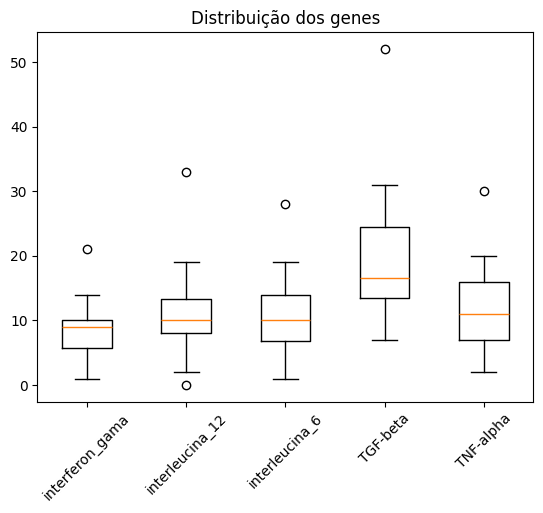

In [48]:
dados = df_amino.drop(columns=["gene", "media_gene"])
plt.boxplot(dados.T, labels=df_amino["gene"])
plt.title("Distribuição dos genes")
plt.xticks(rotation=45)
plt.show()

R.: Os dados concordam. O gene interleucina 12 apresenta maior CV, indicando maior dispersão reativa dos valores. Isso é consistente com o boxplot que mostra variabilidade nos dados, com amplitude interquartil e presença de outliers.

## 10 – Defina uma função que retorne qual o aminoácidos com o maior CV dentre os genes. Obtenha os boxplot dos aminoácidos. Os dados concordam? Porque?

In [3]:
def aa_maior_cv(df):
    cvs = {}
    for col in df.columns:
        if col not in ["gene", "media_gene"]:
            s = df[col]
            cvs[col] = s.std(ddof=1) / s.mean()
    return max(cvs, key=cvs.get), cvs

In [4]:
aa, valores = aa_maior_cv(df_amino)
print(aa)

W


C:\Users\Livia\AppData\Local\Temp\ipykernel_532\721511385.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(dados, labels=dados.columns)


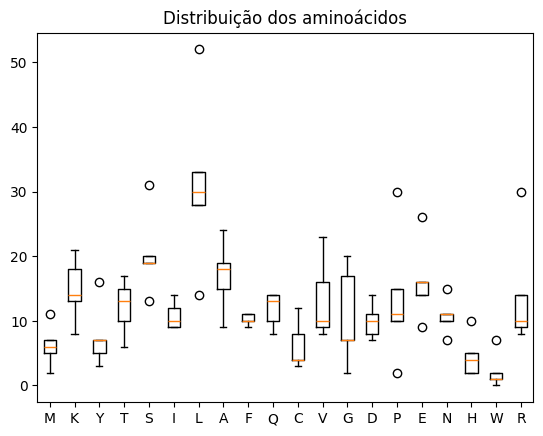

In [5]:
dados = df_amino.drop(columns=["gene", "media_gene"])
plt.boxplot(dados, labels=dados.columns)
plt.title("Distribuição dos aminoácidos")
plt.show()

R.: Aqui os dados não parecem concordar visualmente. O CV mostra a dispersão relativa à média, enquanto o boxplot mostra a dispersão total. No caso do triptofano (W), a média parece ser baixa e por isso o CV da alto, enquanto o boxplot não parece disperso.